**PENGELOMPOKAN TINGKAT POLUSI UDARA MENGGUNAKAN ALGORITMA K-MEANS BERDASARKAN DATA SENSOR LINGKUNGAN**

In [2]:
import json
import pandas as pd

# baca file JSON
with open("/content/kualitas-udara-9ad6e-default-rtdb-export (2).json") as f:
    data = json.load(f)

# ambil data Polusi
polusiAI = data["sensor"]["PolusiAI"]

# ubah ke dataframe
df = pd.DataFrame.from_dict(polusiAI, orient="index")

# jadikan index sebagai id/timestamp
df.reset_index(inplace=True)
df.rename(columns={"index": "id_data"}, inplace=True)

# simpan ke file
df.to_csv("dataset_udara.csv", index=False)
df.to_excel("dataset_udara.xlsx", index=False)

print("Berhasil ambil data POLUSI 🔥")
print(df.head())

Berhasil ambil data POLUSI 🔥
                id_data  kelembaban  mq135   mq2 status_kelembaban  \
0  -OpN7H5L1npgD4d9iZv0        82.0   1140  1349            LEMBAB   
1  -OpN7IW9NxbgXF_tnj2t        82.0   1142  1362            LEMBAB   
2  -OpN7JlczsTQoLTDqAi1        82.0   1136  1363            LEMBAB   
3  -OpN7L1P6wUxuyLlfgbW        82.1   1119  1385            LEMBAB   
4  -OpN7MKX0foanEayH_9H        82.1   1137  1367            LEMBAB   

  status_mq135 status_mq2 status_suhu  suhu            timestamp  
0       SEDANG     SEDANG       PANAS  32.1  2026-04-04 10:54:18  
1       SEDANG     SEDANG       PANAS  32.1  2026-04-04 10:54:24  
2       SEDANG     SEDANG       PANAS  32.1  2026-04-04 10:54:30  
3       SEDANG     SEDANG      NORMAL  32.0  2026-04-04 10:54:35  
4       SEDANG     SEDANG      NORMAL  32.0  2026-04-04 10:54:40  


**1. IMPORT**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score

**2. LOAD DATA**

In [4]:
# load dataset
df = pd.read_excel("/content/dataset_udara.xlsx")

print("=== INFORMASI DATA ===")
print("Jumlah data:", df.shape[0])
print("Jumlah kolom:", df.shape[1])

print("\nNama Kolom:")
print(df.columns)

print("\nTipe Data:")
print(df.dtypes)

print("\nStatistik Deskriptif:")
print(df.describe())

print("\nMissing Value:")
print(df.isnull().sum())

=== INFORMASI DATA ===
Jumlah data: 1410
Jumlah kolom: 10

Nama Kolom:
Index(['id_data', 'kelembaban', 'mq135', 'mq2', 'status_kelembaban',
       'status_mq135', 'status_mq2', 'status_suhu', 'suhu', 'timestamp'],
      dtype='object')

Tipe Data:
id_data               object
kelembaban           float64
mq135                  int64
mq2                    int64
status_kelembaban     object
status_mq135          object
status_mq2            object
status_suhu           object
suhu                 float64
timestamp             object
dtype: object

Statistik Deskriptif:
        kelembaban        mq135          mq2         suhu
count  1410.000000  1410.000000  1410.000000  1410.000000
mean     83.939574  1584.803546  1842.599291    31.450000
std       4.660411  1135.222457  1042.214725     1.740644
min      52.100000   659.000000  1003.000000    28.800000
25%      82.800000   981.000000  1264.000000    30.800000
50%      84.800000  1096.500000  1354.500000    31.100000
75%      85.800000 

**3. PROCESSING**

In [5]:
# hapus kolom yang tidak digunakan
df = df.drop(columns=["id_data", "timestamp"], errors='ignore')

# handle missing value
df = df.dropna()

# pilih fitur numerik
X = df[["mq135", "mq2", "suhu", "kelembaban"]]

# normalisasi
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Data preprocessing selesai")

Data preprocessing selesai


**4. EDA**

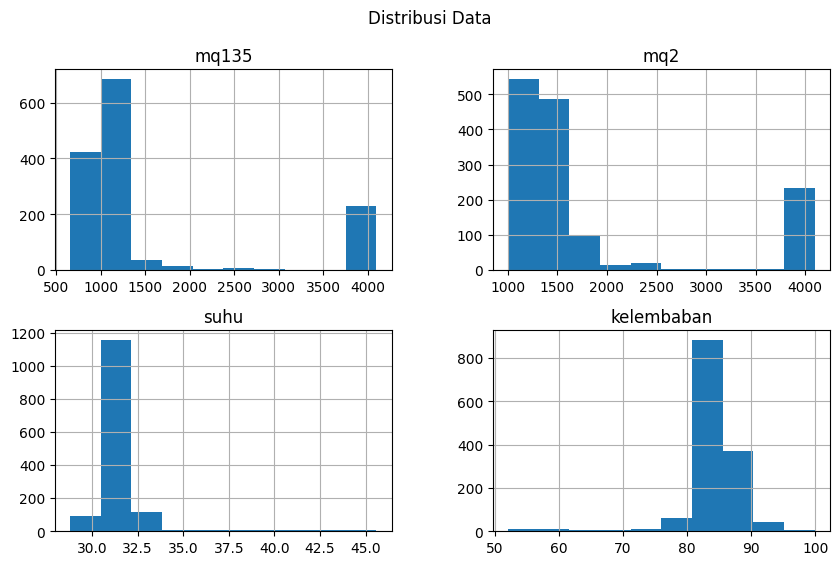

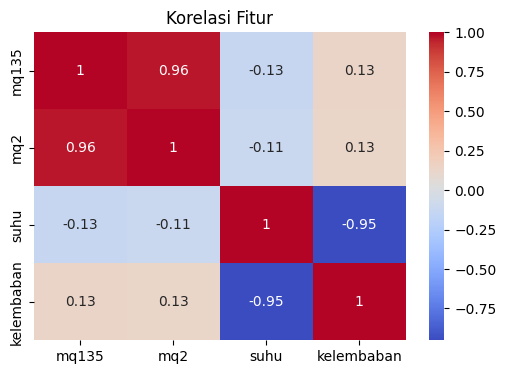

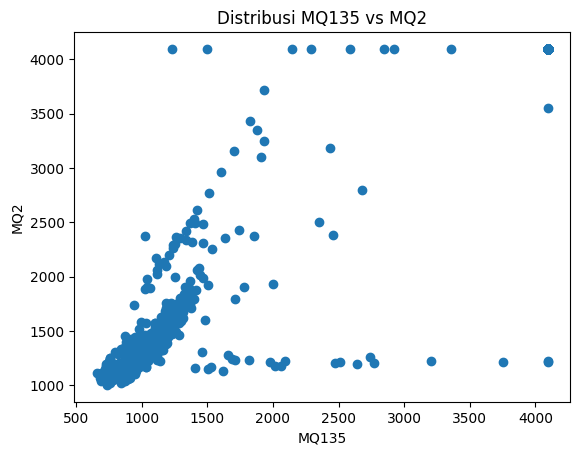

In [6]:
# distribusi data
X.hist(figsize=(10,6))
plt.suptitle("Distribusi Data")
plt.show()

# korelasi
plt.figure(figsize=(6,4))
sns.heatmap(X.corr(), annot=True, cmap='coolwarm')
plt.title("Korelasi Fitur")
plt.show()

# scatter plot
plt.scatter(X["mq135"], X["mq2"])
plt.xlabel("MQ135")
plt.ylabel("MQ2")
plt.title("Distribusi MQ135 vs MQ2")
plt.show()

**5. DATA SPLITTING**

**6. MODEL BUILDING**

In [7]:
print("\n=== MODEL BUILDING AWAL ===")

# KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
label_km = kmeans.fit_predict(X_scaled)

# Agglomerative
agg = AgglomerativeClustering(n_clusters=3)
label_agg = agg.fit_predict(X_scaled)

# DBSCAN
dbs = DBSCAN(eps=0.5, min_samples=5)
label_db = dbs.fit_predict(X_scaled)

print("Model awal berhasil dibuat")


=== MODEL BUILDING AWAL ===
Model awal berhasil dibuat


**7. HYPERPARAMETER TUNING**

In [8]:
# K-MEANS
best_score = -1
best_k = 0

for k in range(2, 6):
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)

    print(f"K={k}, Score={score}")

    if score > best_score:
        best_score = score
        best_k = k

print("Best K:", best_k)


# DBSCAN
best_score = -1
best_eps = 0

for eps in [0.3, 0.5, 0.7, 1.0]:
    dbs = DBSCAN(eps=eps, min_samples=5)
    labels = dbs.fit_predict(X_scaled)

    if len(set(labels)) > 1:
        score = silhouette_score(X_scaled, labels)
        print(f"eps={eps}, Score={score}")

        if score > best_score:
            best_score = score
            best_eps = eps

print("Best eps:", best_eps)


# AGGLOMERATIVE
best_score = -1
best_linkage = ""

for linkage in ["ward", "complete", "average"]:
    agg = AgglomerativeClustering(n_clusters=3, linkage=linkage)
    labels = agg.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)
    print(f"{linkage}: {score}")

    if score > best_score:
        best_score = score
        best_linkage = linkage

print("Best linkage:", best_linkage)

K=2, Score=0.7263267364933975
K=3, Score=0.7797116384066738
K=4, Score=0.5807286093678258
K=5, Score=0.5860881432818699
Best K: 3
eps=0.3, Score=0.5467735572032261
eps=0.5, Score=0.6684406078199139
eps=0.7, Score=0.6769305380404114
eps=1.0, Score=0.6745236851221024
Best eps: 0.7
ward: 0.7735277565075416
complete: 0.28000928252127544
average: 0.7735277565075416
Best linkage: ward


**8. MODEL & EVALUASI**

In [9]:
# KMeans terbaik
km = KMeans(n_clusters=best_k, random_state=42)
label_km = km.fit_predict(X_scaled)

# Agglomerative terbaik
agg = AgglomerativeClustering(n_clusters=3, linkage=best_linkage)
label_agg = agg.fit_predict(X_scaled)

# DBSCAN terbaik
dbs = DBSCAN(eps=best_eps, min_samples=5)
label_db = dbs.fit_predict(X_scaled)

# Evaluasi
sil_km = silhouette_score(X_scaled, label_km)
db_km  = davies_bouldin_score(X_scaled, label_km)

sil_agg = silhouette_score(X_scaled, label_agg)
db_agg  = davies_bouldin_score(X_scaled, label_agg)

if len(set(label_db)) > 1:
    sil_db = silhouette_score(X_scaled, label_db)
    db_db  = davies_bouldin_score(X_scaled, label_db)
else:
    sil_db = 0
    db_db = 0

print("KMeans:", sil_km, db_km)
print("Agglomerative:", sil_agg, db_agg)
print("DBSCAN:", sil_db, db_db)

KMeans: 0.7797116384066738 0.3521242089318755
Agglomerative: 0.7735277565075416 0.30590787904542815
DBSCAN: 0.6769305380404114 1.028507185056021


**9. VISUALISASI CLUSTER**

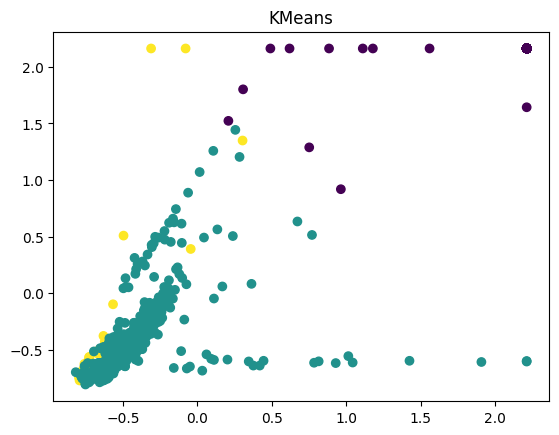

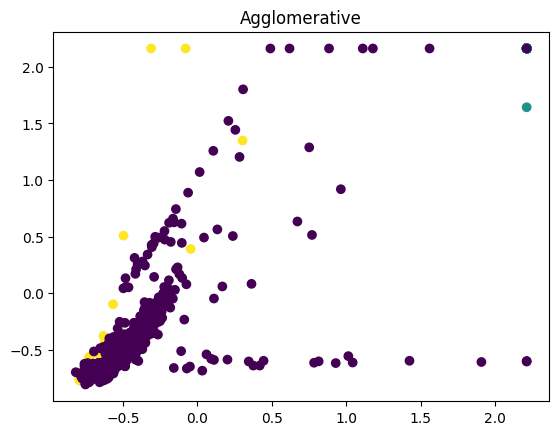

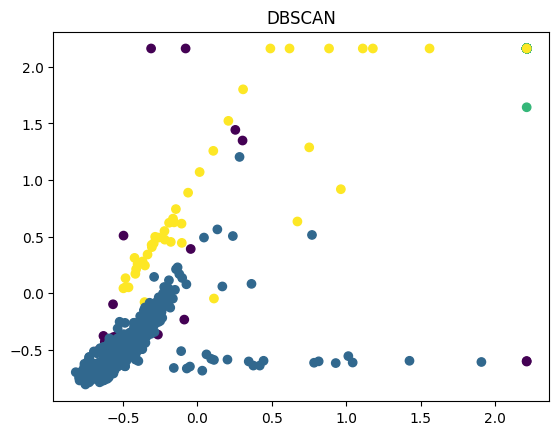

In [10]:
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=label_km)
plt.title("KMeans")
plt.show()

plt.scatter(X_scaled[:,0], X_scaled[:,1], c=label_agg)
plt.title("Agglomerative")
plt.show()

plt.scatter(X_scaled[:,0], X_scaled[:,1], c=label_db)
plt.title("DBSCAN")
plt.show()

**10. COMPARISON**


=== PERBANDINGAN MODEL ===
       Algoritma  Silhouette  Davies-Bouldin
0        K-Means    0.779712        0.352124
1  Agglomerative    0.773528        0.305908
2         DBSCAN    0.676931        1.028507


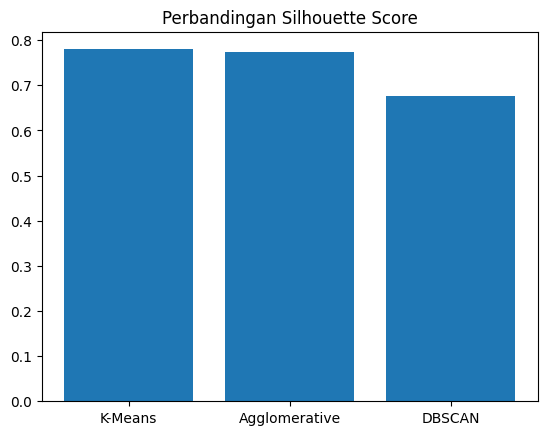

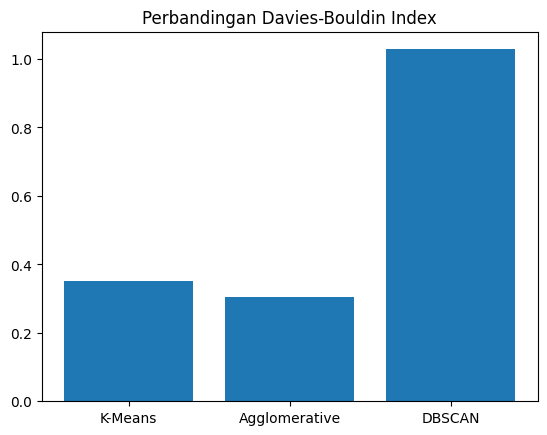

In [11]:
hasil = pd.DataFrame({
    "Algoritma": ["K-Means", "Agglomerative", "DBSCAN"],
    "Silhouette": [sil_km, sil_agg, sil_db],
    "Davies-Bouldin": [db_km, db_agg, db_db]
})

print("\n=== PERBANDINGAN MODEL ===")
print(hasil)

# Grafik Silhouette
plt.bar(hasil["Algoritma"], hasil["Silhouette"])
plt.title("Perbandingan Silhouette Score")
plt.show()

# Grafik DB Index
plt.bar(hasil["Algoritma"], hasil["Davies-Bouldin"])
plt.title("Perbandingan Davies-Bouldin Index")
plt.show()